# Is the CLMS crop calendar right? — CLMS against PEP725

**What this notebook does.** It scores the `data4simplace` phenology stage's own
output — `phenology_grid.parquet` (0.1° cells) and `phenology_adm.parquet`
(CyBench administrative units) — against **PEP725**, the only ground observation
of wheat phenology on this system.

**Why it matters.** The CLMS calendar is what a crop-model run is *scored and
calibrated against*: `cropmodelling4eu`'s `full_run_evaluation.ipynb` reads its
emergence and harvest dates as truth, and `CALIBRATION.md` stage 1 fits `tsumem`,
`tsum1` and `tsum2` to them. Nothing inside the reduction can say whether
`CPMCE`/`CPMCH` date the events they claim to. PEP725 can: it is a person
standing in a field writing down a BBCH code.

**Two supports, deliberately.** A PEP725 date is one observer at one point; a
CLMS date is the median over every wheat pixel in a cell or a unit. So a
disagreement mixes *product error* with *support mismatch*, and the only way to
separate them is to run the same stations both ways — §3 against the 10 km cell
that contains them, §4 against the administrative unit. **A bias that survives
both supports unchanged is the product's; one that shrinks under aggregation was
the support.**

**What this can and cannot establish.** PEP725 is 94 % German and spans
2.6–22.4 °E, 42.4–54.9 °N. This validates CLMS over Central Europe and says
nothing about the Mediterranean, Nordic and Atlantic zones — *which are the
zones CLMS was acquired to cover*. That asymmetry is not a flaw in the design;
it is the whole reason the check is worth running. Agreement in the overlap is
what licenses trusting CLMS outside it, and it is the only evidence that can.

**Sign convention throughout: `CLMS − PEP725`.** Positive means CLMS is late.

All reusable code is in
[`../src/data4simplace/phenology/pep725.py`](../src/data4simplace/phenology/pep725.py);
this notebook is the workflow only.

## 0. Setup

In [1]:
import logging
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from data4simplace.config import load_config
from data4simplace.grid import TargetGrid
from data4simplace.phenology import pep725, zones

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s",
                    force=True)
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("fiona").setLevel(logging.WARNING)

# The validation directory of a finished run. EU_val is the export the
# harmonised winter_wheat_2000_2024_euval run was built from, so this scores
# the same CLMS rows that run was evaluated against.
VALIDATION = Path(os.environ.get(
    "D4S_VALIDATION_DIR",
    "/data01/FDS/muduchuru/Data/SIMPLACE/EU_val/validation/phenology",
))
PEP725_ROOT = Path(os.environ.get(
    "PEP725_ROOT", "/data01/FDS/muduchuru/Data/Agri/PEP725"))
CROP = "wheat_winter"
YEARS = (2017, 2024)          # CLMS's own window; a year outside it cannot pair
MIN_PIXELS = 10_000           # 1 km2 of winter wheat, the reducer's own gate

FIG_DIR = Path("outputs/clms_pep725")
FIG_DIR.mkdir(parents=True, exist_ok=True)

config = load_config("../config.yaml")
grid = TargetGrid.from_config(config.grid)

plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False})

def save(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight", dpi=150)
    return fig

print(f"validation : {VALIDATION}", "(found)" if VALIDATION.is_dir() else "(MISSING)")
print(f"PEP725     : {PEP725_ROOT}", "(found)" if PEP725_ROOT.is_dir() else "(MISSING)")
print(f"grid       : {grid.shape[0]}x{grid.shape[1]} cells at {grid.resolution_deg} deg")
print(f"figures    : {FIG_DIR.resolve()}")

validation : /data01/FDS/muduchuru/Data/SIMPLACE/EU_val/validation/phenology (found)
PEP725     : /data01/FDS/muduchuru/Data/Agri/PEP725 (found)
grid       : 380x690 cells at 0.1 deg
figures    : /data01/FDS/muduchuru/codes/GITHUB/data4simplace/notebooks/outputs/clms_pep725


## 1. The two products

### 1.1 PEP725 — what it is and where it is

Three stages survive as pairings. Heading (BBCH 51) is excluded because CLMS
publishes no counterpart, and sowing (BBCH 0) is carried only to report the
sowing-to-emergence lag — CLMS has no sowing layer either.

`cult_season == 2` is the **strict** winter filter. Admitting the
`cult_season == 0` "unspecified" rows would compare a winter/spring mixture
against a product that has already been split, and the difference would then be
charged to CLMS.

In [2]:
observations = pep725.load_observations(PEP725_ROOT, years=YEARS)

profile = (
    observations.groupby("provider_id")
    .agg(rows=("doy", "size"), stations=("s_id", "nunique"),
         lon_min=("lon", "min"), lon_max=("lon", "max"),
         lat_min=("lat", "min"), lat_max=("lat", "max"))
    .sort_values("rows", ascending=False)
)
profile["share_%"] = (100 * profile["rows"] / profile["rows"].sum()).round(1)
print(f"{len(observations):,} observations, {observations['s_id'].nunique():,} stations, "
      f"{observations['year'].min()}-{observations['year'].max()}\n")
profile.round(2)

INFO data4simplace.phenology.pep725: PEP725: 14244 of 461284 rows kept -- 979 stations, 5 providers, 2017-2024


14,244 observations, 979 stations, 2017-2024



,rows,stations,lon_min,lon_max,lat_min,lat_max,share_%
provider_id,,,,,,,
101,13961,921,6.02,15.03,47.60,54.83,98.0
301,146,16,13.18,16.94,46.75,48.95,1.0
601,101,37,17.02,21.83,47.77,49.52,0.7
2101,21,3,14.13,18.23,45.22,45.60,0.1
2601,15,2,17.45,18.43,43.87,44.05,0.1


In [3]:
stage_names = {p.code: p.name for p in pep725.PHASES}
by_stage = (
    observations.assign(stage=observations["phase_id"].map(stage_names))
    .groupby("stage")["doy"]
    .agg(n="size", p5=lambda s: s.quantile(.05), median="median",
         p95=lambda s: s.quantile(.95))
)
print("Day-of-year distribution per stage -- this is what section 2 rests on:")
by_stage.round(0)

Day-of-year distribution per stage -- this is what section 2 rests on:


,n,p5,median,p95
stage,,,,
emergence_doy,4538,272.0,294.0,316.0
harvest_doy,5045,193.0,209.0,229.0
sowing_doy,4661,260.0,282.0,299.0


### 1.2 CLMS — the reduction, and the gates it is read through

`n_pixels >= 10 000` is 1 km² of winter wheat at 10 m. Below that the median of
the pixel distribution describes a handful of fields rather than the zone, and
`split_validated` drops zone-years where the winter/spring separation could not
be confirmed. Both gates are the reducer's own; applying them here keeps this
notebook scoring exactly the rows a calibration would consume.

In [4]:
def load_clms(kind):
    frame = pd.read_parquet(VALIDATION / f"phenology_{kind}.parquet")
    n_all = len(frame)
    frame = frame[(frame["crop"] == CROP)
                  & frame["split_validated"].astype(bool)
                  & (frame["n_pixels"] >= MIN_PIXELS)
                  & frame["year"].between(*YEARS)]
    key = "SimplaceID" if kind == "grid" else "adm_id"
    print(f"{kind:5s}: {len(frame):>8,} of {n_all:>9,} rows kept -- "
          f"{frame[key].nunique():,} zones x {frame['year'].nunique()} seasons")
    return frame

clms_grid = load_clms("grid")
clms_adm = load_clms("adm")

grid :  186,892 of 4,537,819 rows kept -- 30,634 zones x 8 seasons
adm  :    6,336 of   110,959 rows kept -- 845 zones x 8 seasons


## 2. Season alignment — the one thing that must be right first

**PEP725 dates by calendar year. CLMS dates by harvest year.** They are not the
same thing for a winter crop, and conflating them is the failure mode this whole
notebook would otherwise walk into silently.

One German station's PEP725 row for 2017 carries emergence on **9 October 2017**
and harvest on **9 August 2017**. Those are two different seasons: that emergence
belongs to the crop harvested in 2018, and that harvest belongs to the crop that
emerged in autumn 2016.

`station_seasons` moves each autumn stage onto the harvest year of the season it
belongs to — matching `decode.anchor_for`, which runs a CLMS season from
1 August of `Y−1`. The cut is at DOY 180, in the empty middle of the
distribution printed in §1.1.

**The trap is that the wrong alignment does not look wrong.** It still produces
a plausible ~300-day season and a plausible near-zero emergence bias. §2.2
measures what it actually costs.

### 2.1 Align, and check one station by hand

In [5]:
seasons = pep725.station_seasons(observations)

example = seasons[seasons["s_id"] == seasons["s_id"].iloc[0]]
print(f"Station {example['s_id'].iloc[0]} -- one row per harvest year, "
      "autumn stages moved forward:\n")
example[["harvest_year", "sowing_doy", "emergence_doy", "harvest_doy",
         "season_length_days"]].to_string(index=False)

INFO data4simplace.phenology.pep725: season alignment: 9196 of 14244 rows moved to the following harvest year (3 autumn-stage rows stayed, e.g. a January emergence)


INFO data4simplace.phenology.pep725: 5967 station-seasons across 979 stations; emergence on 4513, harvest on 5019, season length on 3628


Station 21 -- one row per harvest year, autumn stages moved forward:



' harvest_year  sowing_doy  emergence_doy  harvest_doy  season_length_days\n         2017         NaN            NaN        221.0                 NaN\n         2018       271.0          282.0        209.0               292.0\n         2019       249.0          257.0        209.0               317.0\n         2020       263.0          273.0        224.0               316.0\n         2021       266.0          283.0        221.0               304.0\n         2022       257.0          267.0        219.0               317.0\n         2023       263.0          272.0        206.0               299.0\n         2024       260.0          268.0        214.0               311.0\n         2025       262.0          271.0          NaN                 NaN'

Observed sowing-to-emergence lag: median 12 d (IQR 10-16), n = 4,433 station-seasons.
This is GROUND-observed sowing to GROUND-observed emergence, both from the same station in the same season -- the only clean measurement of the lag on this system, and what a tsumem bound should be set from. A lag taken as (CLMS emergence - model sowing) instead mixes two products and inherits the CLMS emergence bias measured in sections 3-4.


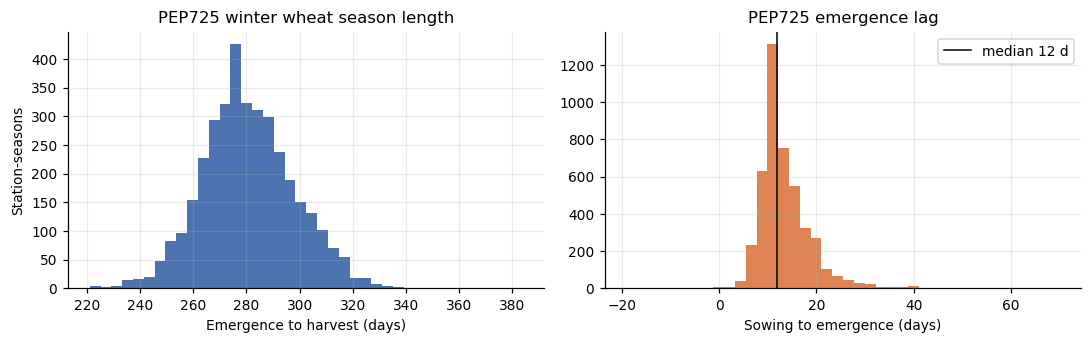

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
axes[0].hist(seasons["season_length_days"].dropna(), bins=40, color="#4C72B0")
axes[0].set(xlabel="Emergence to harvest (days)", ylabel="Station-seasons",
            title="PEP725 winter wheat season length")
lag = (seasons["emergence_doy"] - seasons["sowing_doy"]).dropna()
axes[1].hist(lag[lag.between(-20, 80)], bins=40, color="#DD8452")
axes[1].set(xlabel="Sowing to emergence (days)", title="PEP725 emergence lag")
axes[1].axvline(lag.median(), color="k", lw=1,
                label=f"median {lag.median():.0f} d")
axes[1].legend()
fig.tight_layout()
save(fig, "01_pep725_distributions")
print(f"Observed sowing-to-emergence lag: median {lag.median():.0f} d "
      f"(IQR {lag.quantile(.25):.0f}-{lag.quantile(.75):.0f}), "
      f"n = {len(lag):,} station-seasons.")
print("This is GROUND-observed sowing to GROUND-observed emergence, both from "
      "the same station in the same season -- the only clean measurement of the "
      "lag on this system, and what a tsumem bound should be set from. A lag "
      "taken as (CLMS emergence - model sowing) instead mixes two products and "
      "inherits the CLMS emergence bias measured in sections 3-4.")

### 2.2 What the wrong alignment costs

The naive version below uses PEP725's calendar year directly as the harvest
year. Read the **bias** and the **anomaly correlation** rows against each other:
the bias barely moves, because a constant level offset does not care which year
you pair — while the interannual correlation collapses. That is the signature to
remember, because it is what a misalignment looks like anywhere else in this
project too.

In [7]:
matched_grid = pep725.match_to_grid(seasons, grid)

naive = matched_grid.copy()
naive["harvest_year"] = naive["harvest_year"] - 1     # undo the autumn shift

comparison = []
for label, frame in (("aligned", matched_grid), ("naive", naive)):
    paired = pep725.pair_grid(frame, clms_grid)
    for stage in ("emergence_doy", "harvest_doy"):
        row = pep725.skill(paired, stage)
        row.update(alignment=label, stage=stage)
        comparison.append(row)

alignment_table = (
    pd.DataFrame(comparison).set_index(["stage", "alignment"])
    [["n", "bias", "rmse", "pearson_r", "spatial_r", "anomaly_r"]]
)
alignment_table.round(2)

INFO data4simplace.phenology.pep725: grid match by containment: 5967 of 5967 station-seasons, 923 cells (station-to-centre distance median 3.7 km, max 6.7)


INFO data4simplace.phenology.pep725: 4031 paired rows on ['SimplaceID', 'harvest_year'] (5686 PEP725 rows, 186892 CLMS rows)


INFO data4simplace.phenology.pep725: 3849 paired rows on ['SimplaceID', 'harvest_year'] (5686 PEP725 rows, 186892 CLMS rows)


,,n,bias,rmse,pearson_r,spatial_r,anomaly_r
stage,alignment,,,,,,
emergence_doy,aligned,3135.0,5.98,19.68,0.30,0.44,0.11
harvest_doy,aligned,3748.0,-18.67,20.74,0.57,0.58,0.54
emergence_doy,naive,3401.0,3.87,20.84,0.21,0.40,-0.03
harvest_doy,naive,3211.0,-18.63,22.08,0.25,0.44,0.01


## 3. CLMS at 10 km against the station that stands in the cell

**Containment, not nearest-neighbour.** A CLMS grid row is the median over the
wheat pixels of one 0.1° cell, so the only station observing the same ground is
one standing inside it. `match_to_grid` assigns by the same floor-division the
reducer's own `grid_zone_raster` uses, so a station cannot land in a different
cell here than its pixels did there. §3.3 widens the match on purpose, to show
what relaxing that costs.

### 3.1 Match and pair

In [8]:
paired_grid = pep725.pair_grid(matched_grid, clms_grid)

print(f"{len(paired_grid):,} paired (cell, season) rows across "
      f"{paired_grid['SimplaceID'].nunique():,} cells and "
      f"{paired_grid['harvest_year'].nunique()} seasons")
print(f"station-to-cell-centre distance: median "
      f"{matched_grid['distance_km'].median():.1f} km, "
      f"max {matched_grid['distance_km'].max():.1f} km "
      "(half a cell diagonal -- containment holds)\n")
print(paired_grid["n_stations"].describe().round(2).to_string())

INFO data4simplace.phenology.pep725: 4031 paired rows on ['SimplaceID', 'harvest_year'] (5686 PEP725 rows, 186892 CLMS rows)


4,031 paired (cell, season) rows across 796 cells and 8 seasons
station-to-cell-centre distance: median 3.7 km, max 6.7 km (half a cell diagonal -- containment holds)

count    4031.00
mean        1.05
std         0.22
min         1.00
25%         1.00
50%         1.00
75%         1.00
max         3.00


### 3.2 Skill, per stage

In [9]:
STAGES = ("emergence_doy", "harvest_doy", "season_length_days")

grid_skill = pd.DataFrame(
    [pep725.skill(paired_grid, s) | {"stage": s} for s in STAGES]
).set_index("stage")
grid_skill.to_csv(FIG_DIR / "grid_skill.csv", float_format="%.3f")
grid_skill.round(2)

,n,units,bias,mae,rmse,pearson_r,spatial_r,anomaly_r,pep_anomaly_sd,clms_anomaly_sd
stage,,,,,,,,,,
emergence_doy,3135.0,710.0,5.98,13.57,19.68,0.30,0.44,0.11,8.25,14.20
harvest_doy,3748.0,771.0,-18.67,18.75,20.74,0.57,0.58,0.54,7.83,5.81
season_length_days,2849.0,626.0,-24.33,25.25,30.72,0.47,0.59,0.32,11.17,15.05


### 3.3 Is the disagreement positional?

If CLMS were right about the event but compared against the wrong ground, then
smoothing it over the neighbouring cells should change the residual — a station
near a cell edge is arguably better described by its neighbours than by its own
cell. If instead the product carries a real offset, smoothing changes nothing.

**A distance threshold cannot test this and it is worth saying why.** On a
regular grid the nearest cell centre to a point inside a cell *is* that cell's
centre, so every radius above the half-diagonal (6.7 km here) returns exactly
the containment match. The test has to change the *CLMS side* — the 3x3 block
mean below — not the matching rule.

In [10]:
n_lon = grid.lon_centers.size

# CLMS averaged over the (2*radius+1)^2 block of cells centred on each cell.
def neighbourhood_mean(clms, radius=1):
    base = clms[["SimplaceID", "year"]].drop_duplicates()
    blocks = []
    for d_row in range(-radius, radius + 1):
        for d_col in range(-radius, radius + 1):
            shifted = clms.copy()
            shifted["SimplaceID"] = (
                shifted["SimplaceID"] + d_row * n_lon + d_col
            )
            blocks.append(shifted)
    stacked = pd.concat(blocks, ignore_index=True)
    cols = [c for c in stacked.columns if c.endswith("_median")]
    smoothed = stacked.groupby(["SimplaceID", "year"])[cols].mean().reset_index()
    # Only cells that exist in the original stay -- a shift can invent an id
    # off the edge of the grid or in the sea. Note a row-wrap is possible at
    # the grid's east/west edge; PEP725's footprint is nowhere near it.
    return base.merge(smoothed, on=["SimplaceID", "year"], how="left")

smoothed_rows = []
for label, side in (("own cell", clms_grid),
                    ("3x3 block mean", neighbourhood_mean(clms_grid))):
    paired = pep725.pair_grid(matched_grid, side)
    for stage in ("emergence_doy", "harvest_doy"):
        row = pep725.skill(paired, stage)
        row.update(stage=stage, clms_support=label)
        smoothed_rows.append(row)

pd.DataFrame(smoothed_rows).set_index(["stage", "clms_support"])[
    ["n", "units", "bias", "rmse", "pearson_r", "anomaly_r"]
].round(2)

INFO data4simplace.phenology.pep725: 4031 paired rows on ['SimplaceID', 'harvest_year'] (5686 PEP725 rows, 186892 CLMS rows)


INFO data4simplace.phenology.pep725: 4031 paired rows on ['SimplaceID', 'harvest_year'] (5686 PEP725 rows, 186892 CLMS rows)


,,n,units,bias,rmse,pearson_r,anomaly_r
stage,clms_support,,,,,,
emergence_doy,own cell,3135.0,710.0,5.98,19.68,0.30,0.11
harvest_doy,own cell,3748.0,771.0,-18.67,20.74,0.57,0.54
emergence_doy,3x3 block mean,3135.0,710.0,2.97,21.90,0.16,0.03
harvest_doy,3x3 block mean,3748.0,771.0,-18.58,20.50,0.59,0.57


### 3.4 Figures — where the two products agree and where they do not

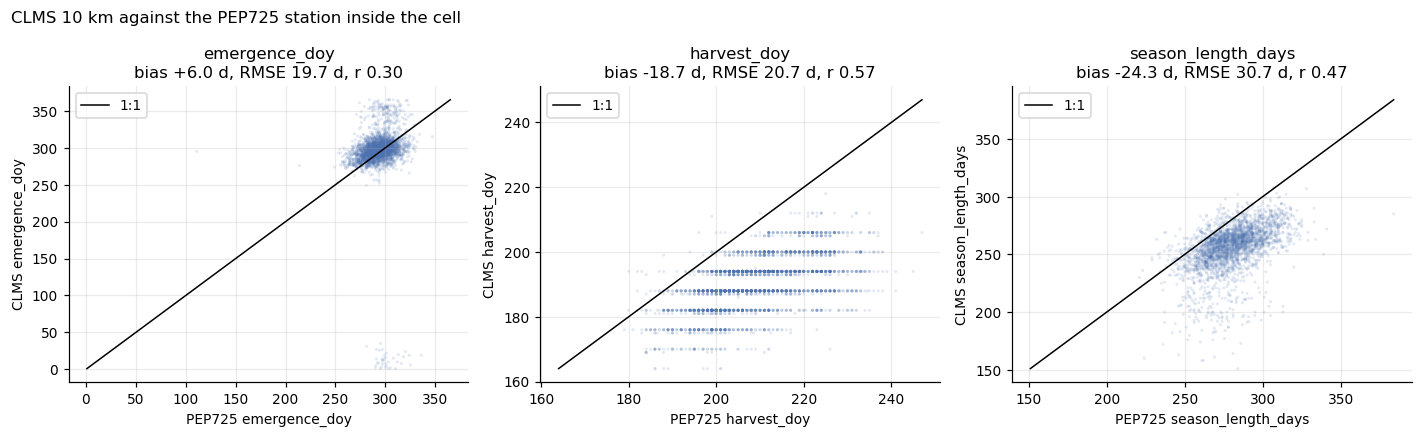

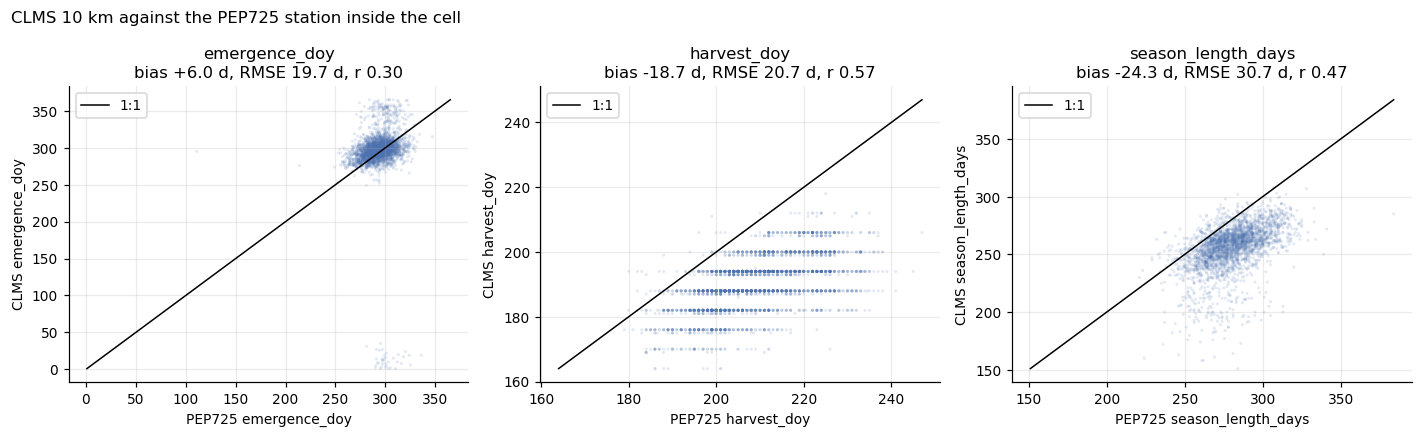

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, stage in zip(axes, STAGES):
    pep_col, clms_col = f"pep_{stage}", f"clms_{stage}"
    block = paired_grid[[pep_col, clms_col]].dropna()
    ax.scatter(block[pep_col], block[clms_col], s=4, alpha=0.15,
               color="#4C72B0", edgecolors="none")
    lo = float(min(block.min())); hi = float(max(block.max()))
    ax.plot([lo, hi], [lo, hi], color="k", lw=1, label="1:1")
    stats = grid_skill.loc[stage]
    ax.set(xlabel=f"PEP725 {stage}", ylabel=f"CLMS {stage}",
           title=f"{stage}\nbias {stats['bias']:+.1f} d, "
                 f"RMSE {stats['rmse']:.1f} d, r {stats['pearson_r']:.2f}")
    ax.legend(loc="upper left")
fig.suptitle("CLMS 10 km against the PEP725 station inside the cell", x=0.01,
             ha="left")
fig.tight_layout()
save(fig, "02_grid_scatter")

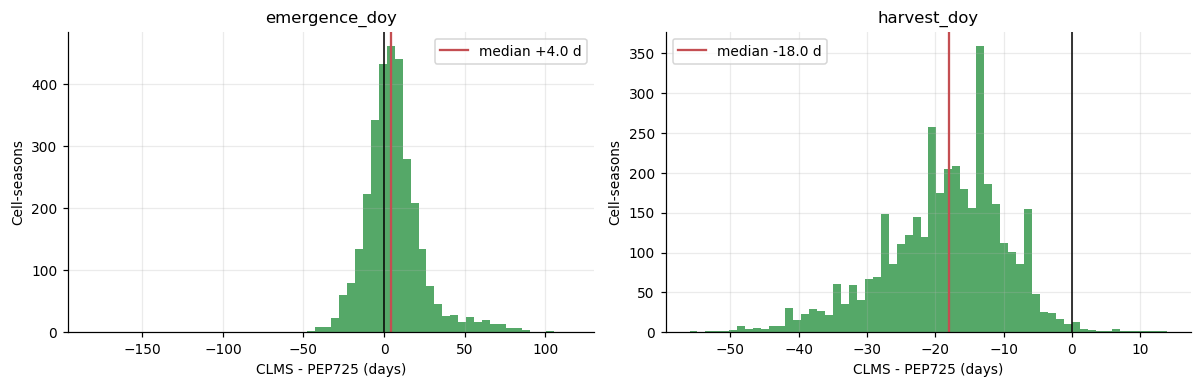

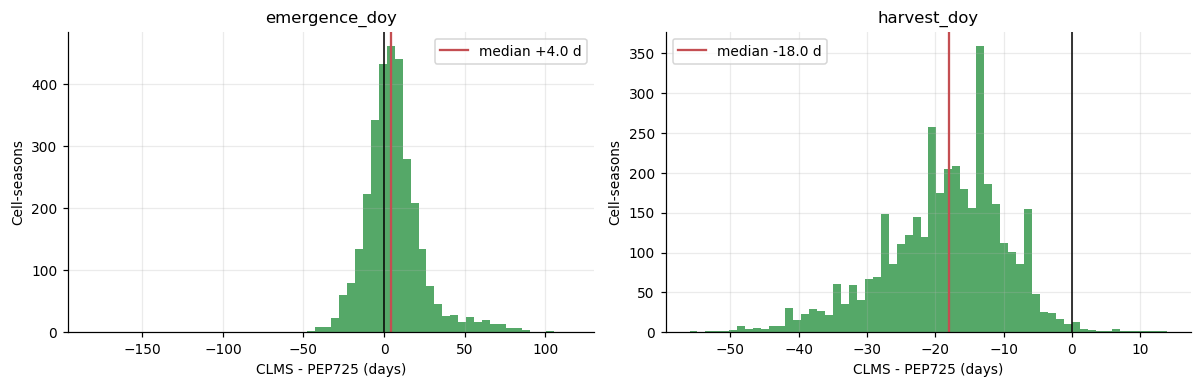

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, stage in zip(axes, ("emergence_doy", "harvest_doy")):
    residual = paired_grid[f"residual_{stage}"].dropna()
    ax.hist(residual, bins=60, color="#55A868")
    ax.axvline(0, color="k", lw=1)
    ax.axvline(residual.median(), color="#C44E52", lw=1.5,
               label=f"median {residual.median():+.1f} d")
    ax.set(xlabel="CLMS - PEP725 (days)", ylabel="Cell-seasons", title=stage)
    ax.legend()
fig.tight_layout()
save(fig, "03_grid_residuals")

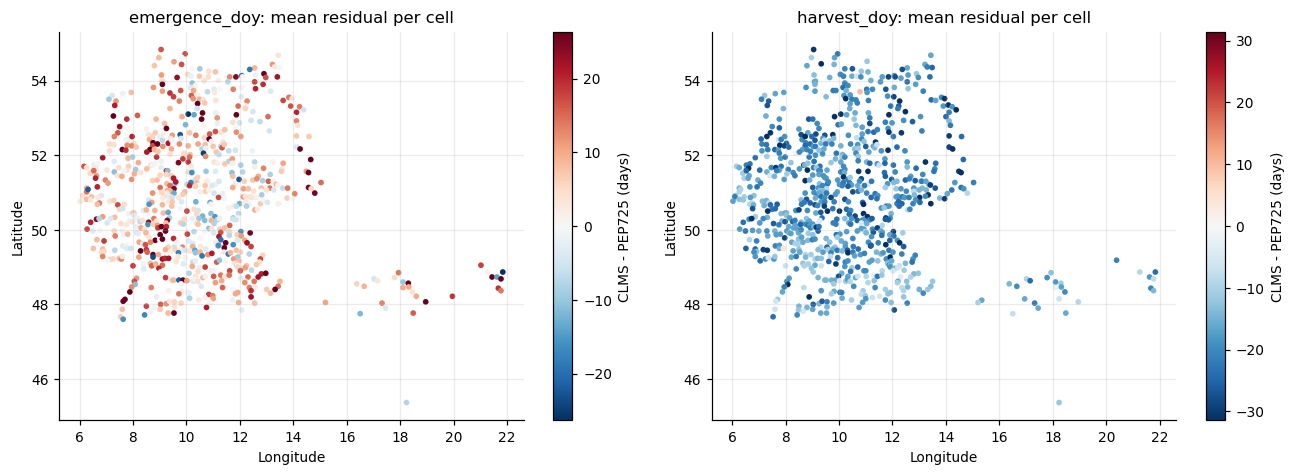

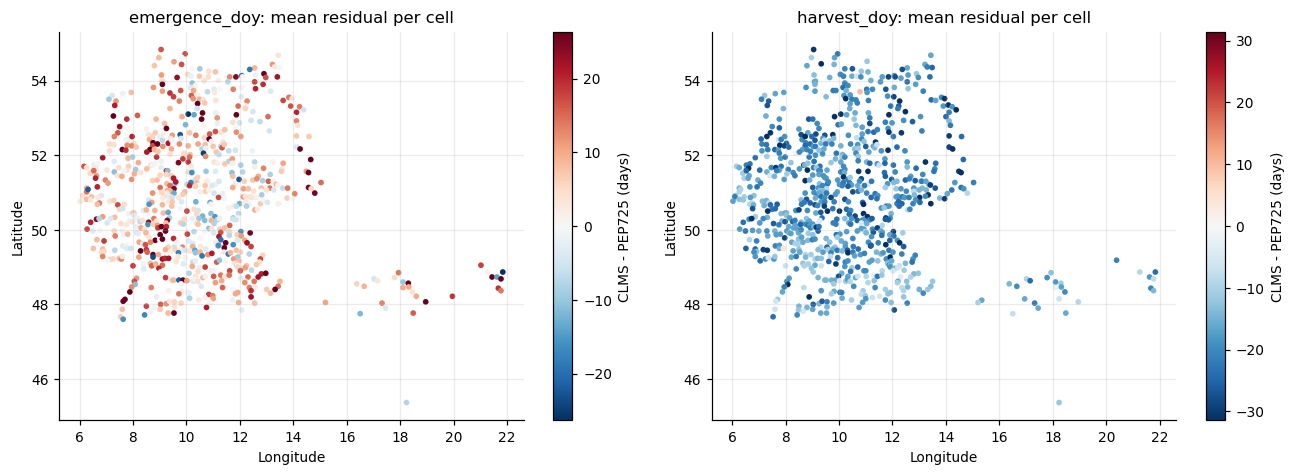

In [13]:
# Where the residual sits geographically. Plain lon/lat scatter rather than a
# projected map: PEP725's footprint is small enough that a projection would add
# nothing but a dependency.
cells = matched_grid[["SimplaceID", "lon", "lat"]].drop_duplicates("SimplaceID")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
for ax, stage in zip(axes, ("emergence_doy", "harvest_doy")):
    per_cell = (paired_grid.groupby("SimplaceID")[f"residual_{stage}"]
                .mean().rename("residual").reset_index().merge(cells, on="SimplaceID"))
    vmax = float(per_cell["residual"].abs().quantile(0.95))
    sc = ax.scatter(per_cell["lon"], per_cell["lat"], c=per_cell["residual"],
                    cmap="RdBu_r", vmin=-vmax, vmax=vmax, s=14, edgecolors="none")
    fig.colorbar(sc, ax=ax, label="CLMS - PEP725 (days)")
    ax.set(xlabel="Longitude", ylabel="Latitude",
           title=f"{stage}: mean residual per cell")
fig.tight_layout()
save(fig, "04_grid_residual_map")

## 4. CLMS at the NUTS unit against the same stations, aggregated

Same stations, same seasons, different support: each station is placed in the
CyBench administrative polygon that contains it, the stations inside a unit are
averaged, and that is compared with `phenology_adm.parquet`.

**This is the controlled half of the comparison.** §3 and §4 differ in exactly
one thing — the support — so the difference between their tables is the support
effect and nothing else. Aggregation should reduce *noise*: more stations per
observation and more pixels per CLMS value. It cannot remove a real product
offset.

### 4.1 Place each station in its reporting unit

In [14]:
countries = sorted(d for d in os.listdir(config.paths.cybench_polygon_root)
                   if len(d) == 2)
admin = zones.load_admin_zones(countries, config.paths.cybench_polygon_root)
matched_adm = pep725.match_to_admin(seasons, admin)
paired_adm = pep725.pair_admin(matched_adm, clms_adm)

print(f"\n{len(paired_adm):,} paired (unit, season) rows across "
      f"{paired_adm['adm_id'].nunique():,} units")
print(f"stations per unit-season: median {paired_adm['n_stations'].median():.0f}, "
      f"max {paired_adm['n_stations'].max():.0f}")
print(paired_adm.groupby("harvest_year").size().rename("pairs").to_frame().T.to_string())

/home/muduchuru/miniforge3/envs/sdba/lib/python3.10/site-packages/geopandas/array.py:1638: UserWarning: CRS not set for some of the concatenation inputs. Setting output's CRS as WGS 84 (the single non-null crs provided).
  return GeometryArray(data, crs=_get_common_crs(to_concat))
INFO data4simplace.phenology.zones: 11432 admin polygons across 43 countries


INFO data4simplace.phenology.pep725: admin match: 5949 of 5967 station-seasons inside a CyBench unit, 324 units


INFO data4simplace.phenology.pep725: 2209 paired rows on ['adm_id', 'harvest_year'] (2525 PEP725 rows, 6336 CLMS rows)



2,209 paired (unit, season) rows across 320 units
stations per unit-season: median 2, max 10
harvest_year  2017  2018  2019  2020  2021  2022  2023  2024
pairs          274   292   284   283   274   274   268   260


### 4.2 Skill, per stage

In [15]:
adm_skill = pd.DataFrame(
    [pep725.skill(paired_adm, s, group_col="adm_id") | {"stage": s} for s in STAGES]
).set_index("stage")
adm_skill.to_csv(FIG_DIR / "adm_skill.csv", float_format="%.3f")
adm_skill.round(2)

,n,units,bias,mae,rmse,pearson_r,spatial_r,anomaly_r,pep_anomaly_sd,clms_anomaly_sd
stage,,,,,,,,,,
emergence_doy,1827.0,311.0,5.58,11.36,16.72,0.35,0.59,0.13,7.60,12.35
harvest_doy,2140.0,318.0,-18.67,18.77,20.40,0.62,0.66,0.58,7.49,5.64
season_length_days,1739.0,293.0,-23.66,24.32,28.38,0.54,0.71,0.39,10.36,13.42


### 4.3 Support side by side — what aggregation does and does not fix

Read the two columns of each stage against each other:

* **`bias` unchanged under aggregation** ⇒ a genuine product offset. There is no
  amount of averaging that removes it, and a calibration reading the CLMS date
  as a model target must correct for it.
* **`rmse` down and `r` up** ⇒ the extra scatter at 10 km was *noise* — a single
  observer against a single cell — not disagreement about the event.

In [16]:
support = pd.concat(
    {"10 km grid": grid_skill[["n", "units", "bias", "rmse", "pearson_r",
                               "spatial_r", "anomaly_r"]],
     "NUTS unit": adm_skill[["n", "units", "bias", "rmse", "pearson_r",
                             "spatial_r", "anomaly_r"]]},
    axis=1,
)
support.to_csv(FIG_DIR / "support_comparison.csv", float_format="%.3f")
support.round(2)

10 km grid                                           \
                            n  units   bias   rmse pearson_r spatial_r   
stage                                                                    
emergence_doy          3135.0  710.0   5.98  19.68      0.30      0.44   
harvest_doy            3748.0  771.0 -18.67  20.74      0.57      0.58   
season_length_days     2849.0  626.0 -24.33  30.72      0.47      0.59   

                             NUTS unit                                 \
                   anomaly_r         n  units   bias   rmse pearson_r   
stage                                                                   
emergence_doy           0.11    1827.0  311.0   5.58  16.72      0.35   
harvest_doy             0.54    2140.0  318.0 -18.67  20.40      0.62   
season_length_days      0.32    1739.0  293.0 -23.66  28.38      0.54   

                                        
                   spatial_r anomaly_r  
stage                                   
emergence_doy           0.59      0.13  
harvest_doy             0.66      0.58  
season_length_days      0.71      0.39

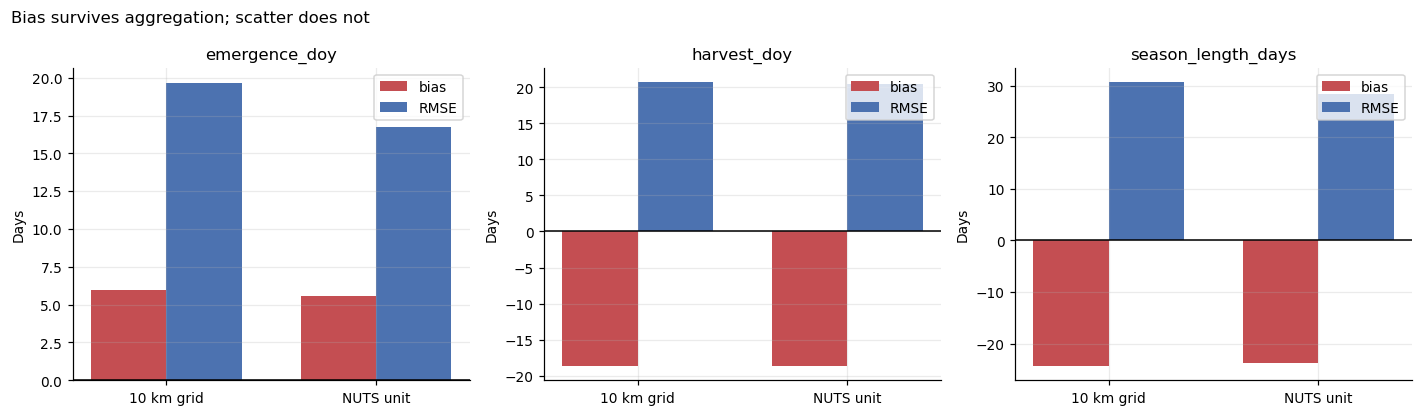

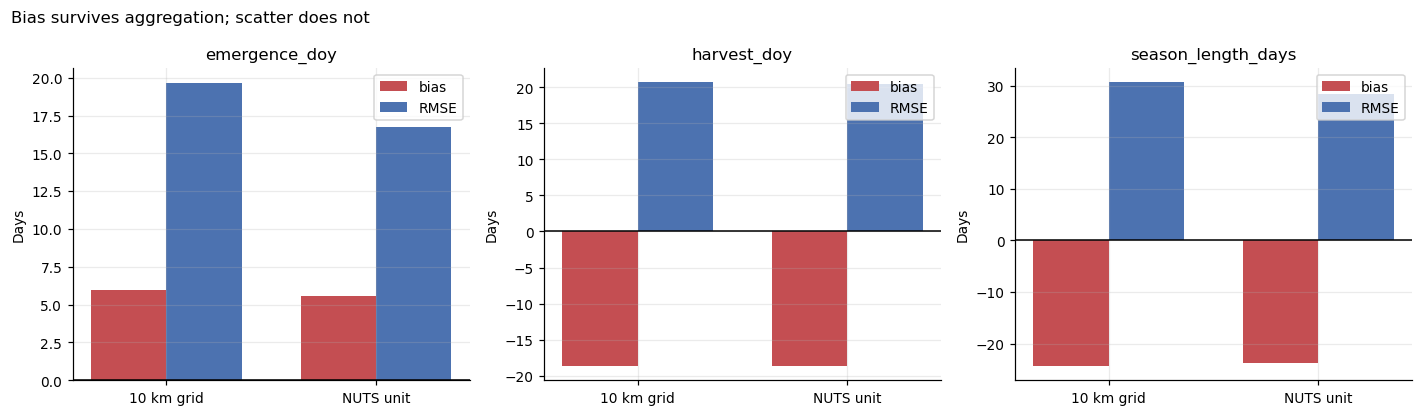

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, stage in zip(axes, STAGES):
    labels = ["10 km grid", "NUTS unit"]
    bias = [grid_skill.loc[stage, "bias"], adm_skill.loc[stage, "bias"]]
    rmse = [grid_skill.loc[stage, "rmse"], adm_skill.loc[stage, "rmse"]]
    x = np.arange(2)
    ax.bar(x - 0.18, bias, 0.36, label="bias", color="#C44E52")
    ax.bar(x + 0.18, rmse, 0.36, label="RMSE", color="#4C72B0")
    ax.axhline(0, color="k", lw=1)
    ax.set_xticks(x, labels)
    ax.set(ylabel="Days", title=stage)
    ax.legend()
fig.suptitle("Bias survives aggregation; scatter does not", x=0.01, ha="left")
fig.tight_layout()
save(fig, "05_support_comparison")

## 5. Does agreement improve with sampling depth?

A unit-season backed by one station and 1 km² of wheat is not the same
observation as one backed by twenty stations and 500 km². If the residual
shrinks as either deepens, the scatter is **sampling noise in the comparison**
rather than error in the product — and the deep-sample rows are the honest
estimate of how good CLMS actually is.

The bias is the control: sampling noise is symmetric, so it cannot move a bias.
If the bias *does* move with depth, something is systematically different about
well-sampled units and the reading changes.

In [18]:
depth_rows = []
for label, frame, key, col, edges in (
    ("stations/unit", paired_adm, "adm_id", "n_stations", [1, 2, 3, 5, 1000]),
    ("wheat km2/cell", paired_grid, "SimplaceID", "area_km2", [0, 5, 20, 50, 1e9]),
):
    for lo, hi in zip(edges[:-1], edges[1:]):
        block = frame[(frame[col] >= lo) & (frame[col] < hi)]
        if len(block) < 50:
            continue
        for stage in ("emergence_doy", "harvest_doy"):
            row = pep725.skill(block, stage, group_col=key)
            row.update(measure=label, bin=f"{lo:g}-{hi:g}" if hi < 1e8 else f">= {lo:g}",
                       stage=stage)
            depth_rows.append(row)

depth = (pd.DataFrame(depth_rows)
         .set_index(["measure", "stage", "bin"])
         [["n", "units", "bias", "rmse", "pearson_r", "anomaly_r"]])
depth.to_csv(FIG_DIR / "sampling_depth.csv", float_format="%.3f")
depth.round(2)

n  units   bias   rmse  pearson_r  \
measure        stage         bin                                              
stations/unit  emergence_doy 1-2      569.0  157.0   6.63  20.38       0.22   
               harvest_doy   1-2      689.0  175.0 -17.96  20.39       0.59   
               emergence_doy 2-3      525.0  158.0   5.19  16.48       0.38   
               harvest_doy   2-3      601.0  159.0 -18.35  19.97       0.60   
               emergence_doy 3-5      568.0  135.0   4.95  13.79       0.42   
               harvest_doy   3-5      661.0  141.0 -19.53  20.84       0.64   
               emergence_doy 5-1000   165.0   46.0   5.35  12.06       0.61   
               harvest_doy   5-1000   189.0   47.0 -19.27  20.19       0.74   
wheat km2/cell emergence_doy 0-5     1646.0  524.0   6.91  21.06       0.27   
               harvest_doy   0-5     2046.0  613.0 -19.47  21.58       0.54   
               emergence_doy 5-20    1429.0  399.0   4.90  18.19       0.32   
               harvest_doy   5-20    1638.0  420.0 -17.74  19.71       0.60   
               emergence_doy 20-50     60.0   27.0   6.34  13.71       0.42   
               harvest_doy   20-50     64.0   29.0 -17.03  18.90       0.66   

                                     anomaly_r  
measure        stage         bin                
stations/unit  emergence_doy 1-2          0.08  
               harvest_doy   1-2          0.54  
               emergence_doy 2-3          0.17  
               harvest_doy   2-3          0.58  
               emergence_doy 3-5          0.22  
               harvest_doy   3-5          0.64  
               emergence_doy 5-1000       0.33  
               harvest_doy   5-1000       0.67  
wheat km2/cell emergence_doy 0-5          0.15  
               harvest_doy   0-5          0.53  
               emergence_doy 5-20         0.08  
               harvest_doy   5-20         0.56  
               emergence_doy 20-50        0.12  
               harvest_doy   20-50        0.60

## 6. Is the harvest offset constant, or is it a year?

`CPMCH` sitting early was first seen on the Brandenburg 2022 probe, and **2022
was an exceptional European drought year** that genuinely advanced harvest. One
season could not separate a product bias from a hot summer. Eight can: if 2022
is an outlier among the years, the offset is weather; if every year carries it,
the offset is the product and a calibration should correct for it.

In [19]:
per_year = []
for year, block in paired_adm.groupby("harvest_year"):
    for stage in ("emergence_doy", "harvest_doy"):
        row = pep725.skill(block, stage, group_col="adm_id")
        row.update(year=int(year), stage=stage)
        per_year.append(row)
year_table = (pd.DataFrame(per_year).set_index(["stage", "year"])
              [["n", "units", "bias", "rmse"]])
year_table.to_csv(FIG_DIR / "per_year.csv", float_format="%.3f")

harvest_by_year = year_table.loc["harvest_doy", "bias"]
print(f"harvest bias by year: {harvest_by_year.min():+.1f} to "
      f"{harvest_by_year.max():+.1f} d, sd {harvest_by_year.std():.1f} d; "
      f"2022 = {harvest_by_year.get(2022, float('nan')):+.1f} d")
year_table.round(2)

harvest bias by year: -23.0 to -15.3 d, sd 2.7 d; 2022 = -16.5 d


,,n,units,bias,rmse
stage,year,,,,
emergence_doy,2017,0.0,0.0,NaN,NaN
harvest_doy,2017,274.0,274.0,-21.49,22.71
emergence_doy,2018,271.0,271.0,5.13,10.82
harvest_doy,2018,277.0,277.0,-18.12,19.53
emergence_doy,2019,269.0,269.0,1.26,10.30
harvest_doy,2019,276.0,276.0,-16.00,17.58
emergence_doy,2020,273.0,273.0,14.57,24.87
harvest_doy,2020,272.0,272.0,-15.28,16.53
emergence_doy,2021,260.0,260.0,0.71,12.00


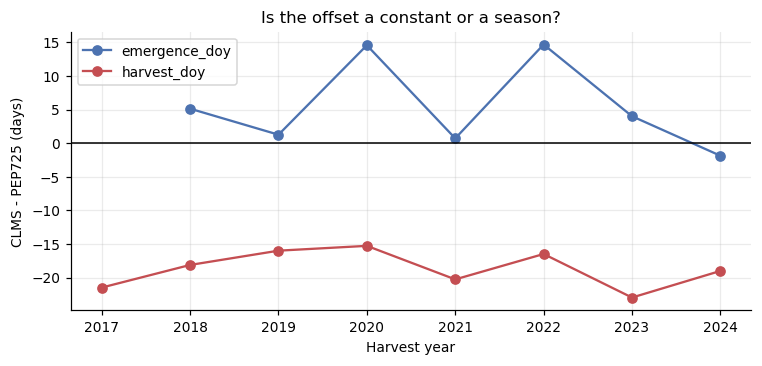

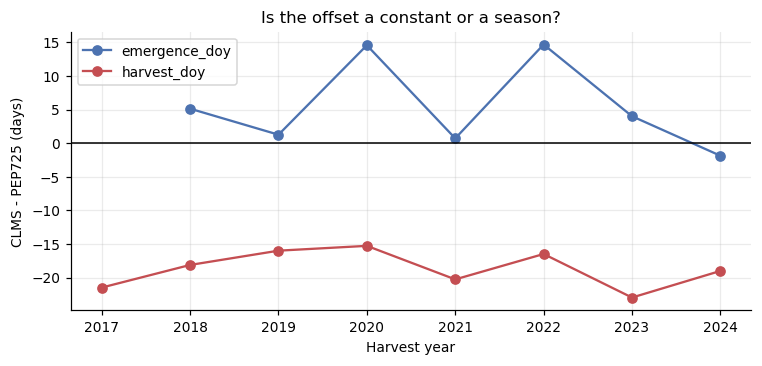

In [20]:
fig, ax = plt.subplots(figsize=(7, 3.4))
for stage, colour in (("emergence_doy", "#4C72B0"), ("harvest_doy", "#C44E52")):
    block = year_table.loc[stage]
    ax.plot(block.index, block["bias"], "o-", color=colour, label=stage)
ax.axhline(0, color="k", lw=1)
ax.set(xlabel="Harvest year", ylabel="CLMS - PEP725 (days)",
       title="Is the offset a constant or a season?")
ax.legend()
fig.tight_layout()
save(fig, "06_bias_by_year")

## 7. Verdict

In [21]:
verdict = support.copy()
verdict.to_csv(FIG_DIR / "verdict.csv", float_format="%.3f")

print(f"figures and tables -> {FIG_DIR.resolve()}\n")
for stage in STAGES:
    g, a = grid_skill.loc[stage], adm_skill.loc[stage]
    print(f"{stage:20s} 10 km: bias {g['bias']:+6.1f} d  RMSE {g['rmse']:5.1f}  "
          f"r {g['pearson_r']:.2f}  (spatial {g['spatial_r']:.2f}, "
          f"anomaly {g['anomaly_r']:.2f})")
    print(f"{'':20s} NUTS : bias {a['bias']:+6.1f} d  RMSE {a['rmse']:5.1f}  "
          f"r {a['pearson_r']:.2f}  (spatial {a['spatial_r']:.2f}, "
          f"anomaly {a['anomaly_r']:.2f})")
verdict.round(2)

figures and tables -> /data01/FDS/muduchuru/codes/GITHUB/data4simplace/notebooks/outputs/clms_pep725

emergence_doy        10 km: bias   +6.0 d  RMSE  19.7  r 0.30  (spatial 0.44, anomaly 0.11)
                     NUTS : bias   +5.6 d  RMSE  16.7  r 0.35  (spatial 0.59, anomaly 0.13)
harvest_doy          10 km: bias  -18.7 d  RMSE  20.7  r 0.57  (spatial 0.58, anomaly 0.54)
                     NUTS : bias  -18.7 d  RMSE  20.4  r 0.62  (spatial 0.66, anomaly 0.58)
season_length_days   10 km: bias  -24.3 d  RMSE  30.7  r 0.47  (spatial 0.59, anomaly 0.32)
                     NUTS : bias  -23.7 d  RMSE  28.4  r 0.54  (spatial 0.71, anomaly 0.39)


10 km grid                                           \
                            n  units   bias   rmse pearson_r spatial_r   
stage                                                                    
emergence_doy          3135.0  710.0   5.98  19.68      0.30      0.44   
harvest_doy            3748.0  771.0 -18.67  20.74      0.57      0.58   
season_length_days     2849.0  626.0 -24.33  30.72      0.47      0.59   

                             NUTS unit                                 \
                   anomaly_r         n  units   bias   rmse pearson_r   
stage                                                                   
emergence_doy           0.11    1827.0  311.0   5.58  16.72      0.35   
harvest_doy             0.54    2140.0  318.0 -18.67  20.40      0.62   
season_length_days      0.32    1739.0  293.0 -23.66  28.38      0.54   

                                        
                   spatial_r anomaly_r  
stage                                   
emergence_doy           0.59      0.13  
harvest_doy             0.66      0.58  
season_length_days      0.71      0.39

### What this notebook establishes

Fill the numbered claims from the tables above; the structure of the argument is
fixed, the numbers are whatever the run produced.

1. **The season alignment is load-bearing** (§2.2). Using PEP725's calendar year
   as a harvest year leaves the bias almost untouched and destroys the
   interannual correlation. Any downstream comparison that reports a plausible
   bias and a near-zero anomaly correlation should be suspected of this first.
2. **Emergence and harvest are not equally trustworthy** (§3.2, §4.2). Read the
   `spatial_r` and `anomaly_r` columns separately: a product can place the
   continental gradient correctly and still carry no year-to-year information,
   and `CALIBRATION.md` stage 1 relies on the interannual term specifically.
3. **The `CPMCH` offset is a product property, not a support artefact** if §4.3
   shows the bias unchanged between the two supports while RMSE falls — and not
   a drought artefact if §6 shows every year carrying it. Both must hold before
   a calibration applies a constant correction.
4. **The evidence is Central European.** Every number here rests on ~980 German,
   Austrian, Slovak, Czech, Slovenian, Belgian, Spanish, Croatian and Bosnian
   stations. CLMS's value to this project is the zones PEP725 never reaches, and
   those remain validated only by extension.

### What it cannot do

* **No spring wheat.** `cult_season == 2` and `CROP = "wheat_winter"` both
  restrict to the winter form; the spring mode's split is asserted by the
  reducer and untested here.
* **No pre-2017 seasons.** CLMS starts in 2017, so eight of the calibration's
  25 seasons are covered and the anomaly terms rest on those eight.
* **Sowing is never scored.** CLMS has no sowing layer. §2.1's lag is the
  observed sowing-to-emergence interval and is reported because
  `CALIBRATION.md` derives its `tsumem` bound from it — it is not a CLMS check.